<a href="https://colab.research.google.com/github/angeruzzi/home-credit-default-risk/blob/main/notebooks/07_model_comparison_and_champion_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 07 — Comparação de Modelos e Seleção do Champion

## Introdução

### 1. Contexto

Os notebooks anteriores desenvolveram duas abordagens para estimar o risco de dificuldade de pagamento:

- **modelo tradicional:** Binning, WoE e Logistic Regression;
- **modelo challenger:** LightGBM com interpretabilidade por SHAP.

Os dois modelos foram treinados e avaliados utilizando as mesmas amostras de train, validation e holdout test.

Este notebook realizará a comparação consolidada entre as abordagens e traduzirá as probabilidades estimadas em instrumentos mais próximos de uma aplicação de negócio:

$$
PD
\rightarrow
Score
\rightarrow
Faixas\ de\ risco
\rightarrow
Simulação\ de\ política
$$

A comparação não será baseada apenas na maior métrica pontual.

Serão considerados:

- discriminação;
- calibração;
- incerteza estatística;
- estabilidade;
- interpretabilidade;
- complexidade;
- governança;
- fairness;
- aplicabilidade em Política de Crédito.

O modelo com melhor ROC-AUC não será automaticamente declarado champion. A decisão deverá considerar se o ganho preditivo compensa os custos adicionais de complexidade, explicação e monitoramento.

### 2. Modelos comparados

#### Logistic Regression

O modelo tradicional utiliza:

- optimal binning;
- transformação Weight of Evidence;
- seleção por Information Value;
- análise de estabilidade;
- controle de correlação e VIF;
- regularização L2;
- coeficientes com sinais consistentes.

Essa abordagem oferece maior transparência e permite relacionar diretamente bins, WoE, coeficientes e risco estimado.

#### LightGBM Challenger

O challenger utiliza:

- 325 features candidatas;
- tratamento nativo de missing values;
- tratamento nativo de categóricas;
- relações não lineares;
- interações entre features;
- regularização;
- early stopping;
- feature importance e SHAP.

Essa abordagem possui maior flexibilidade preditiva, mas exige mecanismos adicionais de explicação e governança.

### 3. Objetivos

Os principais objetivos deste notebook são:

1. carregar as previsões e métricas persistidas pelos dois modelos;
2. validar que as previsões correspondem exatamente aos mesmos clientes;
3. comparar ROC-AUC, Gini, KS, PR-AUC, Brier Score e Log Loss;
4. estimar por bootstrap pareado a incerteza das diferenças;
5. comparar a calibração por faixas de risco;
6. avaliar a concordância de ordenação entre os modelos;
7. discutir interpretabilidade e complexidade;
8. avaliar pontos de atenção de fairness e governança;
9. selecionar o modelo champion para fins do projeto;
10. transformar PD em score;
11. construir ratings ou faixas de risco;
12. simular cutoffs de Política de Crédito;
13. demonstrar o trade-off entre taxa de aprovação e bad rate;
14. consolidar as limitações e recomendações finais.

### 4. Separação entre modelo e Política de Crédito

O modelo estima risco, mas não determina sozinho se uma proposta deve ser aprovada.

A decisão de crédito pode considerar:

- PD;
- elegibilidade;
- renda e capacidade de pagamento;
- valor solicitado;
- garantias;
- exposição existente;
- concentração;
- custo de capital;
- rentabilidade esperada;
- apetite a risco;
- limites regulatórios;
- regras de negócio.

Neste projeto, a simulação de cutoffs terá finalidade demonstrativa.

> O cutoff não será escolhido por maximização automática de accuracy, F1 ou KS. Sua definição representa uma decisão de negócio que equilibra aprovação, risco, retorno e capacidade de absorção de perdas.

Como a base não contém informações suficientes sobre LGD, EAD, margem, custo de capital e rentabilidade, a análise de política será limitada ao trade-off entre taxa de aprovação e bad rate observado.

### 5. Fairness e governança

A análise de SHAP mostrou que `CODE_GENDER` possui contribuição relevante para o LightGBM.

A presença de uma feature preditiva não significa que seu uso seja automaticamente aceitável em uma decisão de crédito.

Neste notebook, serão diferenciados:

- desempenho estatístico;
- adequação para uso;
- risco de discriminação;
- necessidade de análise jurídica e regulatória;
- utilização de atributos para monitoramento de fairness.

A análise realizada será exploratória e não substituirá uma avaliação jurídica, regulatória ou institucional.

O modelo será tratado como estudo de portfólio, e não como solução pronta para produção.

## Configuração do Ambiente

Esta seção prepara o ambiente, instala as dependências do projeto e configura os diretórios de dados, artefatos e relatórios.

Os modelos não serão treinados novamente neste notebook. Serão utilizados os artefatos e as previsões persistidas nos notebooks anteriores.

In [1]:
# Inicialização do ambiente
import os
import sys
import subprocess
from pathlib import Path
import importlib

IN_COLAB = "google.colab" in sys.modules

REPOSITORY_URL = (
    "https://github.com/angeruzzi/home-credit-default-risk.git"
)

if IN_COLAB:
    PROJECT_ROOT = Path(
        "/content/home-credit-default-risk"
    )

    if not (PROJECT_ROOT / ".git").exists():
        subprocess.run(
            [
                "git",
                "clone",
                REPOSITORY_URL,
                str(PROJECT_ROOT),
            ],
            check=True,
        )

    else:
        git_status = subprocess.run(
            [
                "git",
                "-C",
                str(PROJECT_ROOT),
                "status",
                "--porcelain",
            ],
            capture_output=True,
            text=True,
            check=True,
        )

        if git_status.stdout.strip():
            print(
                "O repositório possui alterações locais. "
                "O git pull automático não será executado."
            )
            print(git_status.stdout)

        else:
            subprocess.run(
                [
                    "git",
                    "-C",
                    str(PROJECT_ROOT),
                    "pull",
                    "--ff-only",
                    "origin",
                    "main",
                ],
                check=True,
            )

else:
    current_directory = Path.cwd().resolve()

    PROJECT_ROOT = (
        current_directory.parent
        if current_directory.name == "notebooks"
        else current_directory
    )

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print(f"Raiz do projeto: {PROJECT_ROOT}")

Raiz do projeto: /content/home-credit-default-risk


In [2]:
# Instalação das dependências
REQUIREMENTS_PATH = (
    PROJECT_ROOT / "requirements.txt"
)

if not REQUIREMENTS_PATH.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: "
        f"{REQUIREMENTS_PATH}"
    )

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "-r",
        str(REQUIREMENTS_PATH),
    ],
    check=True,
)

print(
    "Dependências instaladas com sucesso."
)

Dependências instaladas com sucesso.


In [3]:
# Configuração dos diretórios do projeto
import utils

importlib.reload(utils)

from utils import setup_project

paths = setup_project(
    use_google_drive_cache=True,
)

print(paths)

Mounted at /content/drive
Ambiente Colab: True
Modo de armazenamento: Google Drive
Raiz do projeto: /content/home-credit-default-risk
Dados: /content/drive/MyDrive/home-credit-default-risk/data
Artefatos: /content/drive/MyDrive/home-credit-default-risk/artifacts
Relatórios: /content/home-credit-default-risk/reports
ProjectPaths(project_root=PosixPath('/content/home-credit-default-risk'), data_root=PosixPath('/content/drive/MyDrive/home-credit-default-risk/data'), data_raw=PosixPath('/content/drive/MyDrive/home-credit-default-risk/data/raw'), data_interim=PosixPath('/content/drive/MyDrive/home-credit-default-risk/data/interim'), data_processed=PosixPath('/content/drive/MyDrive/home-credit-default-risk/data/processed'), artifacts_root=PosixPath('/content/drive/MyDrive/home-credit-default-risk/artifacts'), models=PosixPath('/content/drive/MyDrive/home-credit-default-risk/artifacts/models'), preprocessing=PosixPath('/content/drive/MyDrive/home-credit-default-risk/artifacts/preprocessing'),

In [4]:
# Importação das bibliotecas
import json
import platform
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn

from IPython.display import display
from scipy.stats import spearmanr
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    200,
)

pd.set_option(
    "display.max_rows",
    200,
)

pd.set_option(
    "display.float_format",
    "{:,.4f}".format,
)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

RANDOM_STATE = 42
TARGET_COLUMN = "TARGET"
ID_COLUMN = "SK_ID_CURR"

print(
    "Bibliotecas importadas com sucesso."
)

Bibliotecas importadas com sucesso.


### 6. Registro das versões

As versões das bibliotecas utilizadas na comparação serão registradas para garantir rastreabilidade dos resultados.

In [5]:
# Registro das versões
library_versions = pd.DataFrame(
    [
        {
            "component": "Python",
            "version": (
                platform.python_version()
            ),
        },
        {
            "component": "NumPy",
            "version": np.__version__,
        },
        {
            "component": "Pandas",
            "version": pd.__version__,
        },
        {
            "component": "SciPy",
            "version": scipy.__version__,
        },
        {
            "component": "Scikit-learn",
            "version": sklearn.__version__,
        },
        {
            "component": "Joblib",
            "version": joblib.__version__,
        },
    ]
)

display(library_versions)

,component,version
0,Python,3.13.15
1,NumPy,2.1.3
2,Pandas,2.2.3
3,SciPy,1.16.3
4,Scikit-learn,1.6.1
5,Joblib,1.6.0


In [6]:
# Persistência das versões
VERSIONS_PATH = (
    paths.metadata
    / "model_comparison_versions.csv"
)

library_versions.to_csv(
    VERSIONS_PATH,
    index=False,
)

print(
    f"Versões registradas em: "
    f"{VERSIONS_PATH}"
)

Versões registradas em: /content/drive/MyDrive/home-credit-default-risk/artifacts/metadata/model_comparison_versions.csv


## Carregamento das Previsões

As previsões persistidas pelos dois modelos serão carregadas e combinadas pelo identificador do cliente, target e amostra.

A comparação será realizada de maneira pareada: para cada cliente, serão confrontadas a PD da Logistic Regression e a PD do LightGBM.

In [7]:
# Definição dos arquivos de previsões
TRADITIONAL_PREDICTIONS_PATH = (
    paths.data_processed
    / "traditional_model_predictions.parquet"
)

CHALLENGER_PREDICTIONS_PATH = (
    paths.data_processed
    / "lightgbm_challenger_predictions.parquet"
)

prediction_paths = {
    "traditional": (
        TRADITIONAL_PREDICTIONS_PATH
    ),
    "challenger": (
        CHALLENGER_PREDICTIONS_PATH
    ),
}

for model_name, file_path in (
    prediction_paths.items()
):
    print(
        f"{model_name}: "
        f"{file_path} | "
        f"existe={file_path.exists()}"
    )

traditional: /content/drive/MyDrive/home-credit-default-risk/data/processed/traditional_model_predictions.parquet | existe=True
challenger: /content/drive/MyDrive/home-credit-default-risk/data/processed/lightgbm_challenger_predictions.parquet | existe=True


In [8]:
# Interrupção se houver arquivos ausentes
missing_prediction_files = [
    str(file_path)
    for file_path in prediction_paths.values()
    if not file_path.exists()
]

if missing_prediction_files:
    raise FileNotFoundError(
        "Os seguintes arquivos não foram encontrados:\n"
        + "\n".join(
            missing_prediction_files
        )
    )

print(
    "Arquivos de previsões encontrados."
)

Arquivos de previsões encontrados.


In [9]:
# Leitura das previsões
traditional_predictions = (
    pd.read_parquet(
        TRADITIONAL_PREDICTIONS_PATH
    )
)

challenger_predictions = (
    pd.read_parquet(
        CHALLENGER_PREDICTIONS_PATH
    )
)

print(
    "Traditional predictions: "
    f"{traditional_predictions.shape}"
)

print(
    "Challenger predictions: "
    f"{challenger_predictions.shape}"
)

Traditional predictions: (307511, 4)
Challenger predictions: (307511, 4)


In [10]:
# Validação individual das previsões
required_prediction_columns = {
    ID_COLUMN,
    TARGET_COLUMN,
    "sample",
    "predicted_pd",
}

for model_name, prediction_df in {
    "traditional": (
        traditional_predictions
    ),
    "challenger": (
        challenger_predictions
    ),
}.items():
    missing_columns = (
        required_prediction_columns
        - set(prediction_df.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{model_name} não contém: "
            f"{sorted(missing_columns)}"
        )

    if prediction_df[
        [
            ID_COLUMN,
            "sample",
        ]
    ].duplicated().any():
        raise ValueError(
            f"{model_name} contém "
            "previsões duplicadas."
        )

    if prediction_df[
        "predicted_pd"
    ].isna().any():
        raise ValueError(
            f"{model_name} contém "
            "probabilidades ausentes."
        )

    if not prediction_df[
        "predicted_pd"
    ].between(
        0,
        1,
        inclusive="both",
    ).all():
        raise ValueError(
            f"{model_name} contém "
            "probabilidades inválidas."
        )

print(
    "Previsões individuais validadas."
)

Previsões individuais validadas.


In [11]:
# Combinação pareada das previsões
traditional_comparison_data = (
    traditional_predictions.rename(
        columns={
            "predicted_pd": (
                "traditional_pd"
            ),
        }
    )
)

challenger_comparison_data = (
    challenger_predictions.rename(
        columns={
            "predicted_pd": (
                "challenger_pd"
            ),
        }
    )
)

model_comparison_data = (
    traditional_comparison_data.merge(
        challenger_comparison_data,
        on=[
            ID_COLUMN,
            TARGET_COLUMN,
            "sample",
        ],
        how="inner",
        validate="one_to_one",
    )
)

print(
    "Registros após o pareamento: "
    f"{len(model_comparison_data):,}"
)

Registros após o pareamento: 307,511


In [12]:
# Validação da cobertura do pareamento
expected_records = len(
    traditional_predictions
)

if (
    len(model_comparison_data)
    != expected_records
    or len(model_comparison_data)
    != len(challenger_predictions)
):
    raise ValueError(
        "As previsões dos modelos não possuem "
        "a mesma cobertura."
    )

comparison_sample_summary = (
    model_comparison_data
    .groupby(
        "sample",
        observed=True,
    )
    .agg(
        clients=(
            ID_COLUMN,
            "size",
        ),
        events=(
            TARGET_COLUMN,
            "sum",
        ),
        event_rate=(
            TARGET_COLUMN,
            "mean",
        ),
        traditional_mean_pd=(
            "traditional_pd",
            "mean",
        ),
        challenger_mean_pd=(
            "challenger_pd",
            "mean",
        ),
    )
    .reset_index()
)

display(
    comparison_sample_summary
)

,sample,clients,events,event_rate,traditional_mean_pd,challenger_mean_pd
0,holdout_test,46127,3724,0.0807,0.0805,0.0804
1,train,215257,17377,0.0807,0.0807,0.0808
2,validation,46127,3724,0.0807,0.0807,0.0807


### 7. Validação da Base de Comparação

As previsões dos dois modelos foram consolidadas utilizando o identificador do cliente, a amostra e o target observado.

Essa validação é necessária para assegurar que a comparação seja realizada sobre os mesmos clientes. Como cada observação possui uma previsão da Logistic Regression e uma previsão do LightGBM, as métricas e os testes de incerteza poderão explorar a natureza pareada dos resultados.

As três amostras apresentam a quantidade esperada de clientes e a mesma taxa de eventos utilizada nos notebooks de modelagem. As médias das PDs também permanecem próximas da taxa observada de eventos, indicando boa calibração global dos dois modelos.

A proximidade entre a PD média e a taxa de eventos é uma verificação agregada. Ela não substitui a avaliação da calibração ao longo das diferentes faixas de risco, que será realizada posteriormente.

## Comparação de Performance

### 8. Métricas por Modelo e Amostra

As principais métricas dos dois modelos serão reconstruídas a partir das previsões consolidadas. Essa abordagem garante que a comparação seja realizada utilizando as mesmas funções e os mesmos critérios.

Serão avaliadas:

- **ROC-AUC:** capacidade global de ordenação entre clientes com e sem evento;
- **Gini:** transformação linear da ROC-AUC, frequentemente utilizada em risco de crédito;
- **KS:** maior distância entre as distribuições acumuladas de clientes com e sem evento;
- **PR-AUC:** capacidade de identificar eventos considerando o desbalanceamento do target;
- **Brier Score:** erro quadrático médio das probabilidades previstas;
- **Log Loss:** penalização probabilística que atribui maior peso a previsões incorretas e excessivamente confiantes;
- **PD média:** risco médio estimado pelo modelo;
- **Taxa de eventos observada:** proporção efetivamente observada de clientes com dificuldade de pagamento.

Para ROC-AUC, Gini, KS e PR-AUC, valores maiores indicam melhor desempenho. Para Brier Score e Log Loss, valores menores são preferíveis.

O `holdout_test` será utilizado como principal referência para a comparação final, pois não participou da seleção de features, do ajuste de hiperparâmetros ou da escolha das configurações dos modelos.

In [13]:
# Cálculo das métricas de performance
def calculate_binary_metrics(
    y_true,
    predicted_probability,
):
    y_true = np.asarray(y_true)
    predicted_probability = np.asarray(
        predicted_probability
    )

    false_positive_rate, true_positive_rate, _ = (
        roc_curve(
            y_true,
            predicted_probability,
        )
    )

    roc_auc = roc_auc_score(
        y_true,
        predicted_probability,
    )

    return {
        "roc_auc": roc_auc,
        "gini": 2 * roc_auc - 1,
        "ks": np.max(
            true_positive_rate - false_positive_rate
        ),
        "pr_auc": average_precision_score(
            y_true,
            predicted_probability,
        ),
        "brier_score": brier_score_loss(
            y_true,
            predicted_probability,
        ),
        "log_loss": log_loss(
            y_true,
            predicted_probability,
        ),
        "mean_predicted_pd": (
            predicted_probability.mean()
        ),
        "observed_event_rate": y_true.mean(),
    }

In [14]:
# Reconstrução das métricas dos dois modelos
model_columns = {
    "Logistic Regression": "traditional_pd",
    "LightGBM Challenger": "challenger_pd",
}

sample_order = [
    "train",
    "validation",
    "holdout_test",
]

comparison_metrics_records = []

for sample_name in sample_order:
    sample_data = model_comparison_data.loc[
        model_comparison_data["sample"].eq(
            sample_name
        )
    ].copy()

    for model_name, probability_column in (
        model_columns.items()
    ):
        metrics = calculate_binary_metrics(
            y_true=sample_data[TARGET_COLUMN],
            predicted_probability=sample_data[
                probability_column
            ],
        )

        comparison_metrics_records.append(
            {
                "model": model_name,
                "sample": sample_name,
                "clients": len(sample_data),
                **metrics,
            }
        )

comparison_metrics = pd.DataFrame(
    comparison_metrics_records
)

comparison_metrics["sample"] = pd.Categorical(
    comparison_metrics["sample"],
    categories=sample_order,
    ordered=True,
)

comparison_metrics = (
    comparison_metrics
    .sort_values(
        ["sample", "model"]
    )
    .reset_index(drop=True)
)

display(comparison_metrics)

,model,sample,clients,roc_auc,gini,ks,pr_auc,brier_score,log_loss,mean_predicted_pd,observed_event_rate
0,LightGBM Challenger,train,215257,0.8370,0.6741,0.5178,0.3770,0.0613,0.2181,0.0808,0.0807
1,Logistic Regression,train,215257,0.7642,0.5284,0.3941,0.2480,0.0675,0.2445,0.0807,0.0807
2,LightGBM Challenger,validation,46127,0.7912,0.5824,0.4423,0.2876,0.0656,0.2356,0.0807,0.0807
3,Logistic Regression,validation,46127,0.7618,0.5237,0.3950,0.2461,0.0676,0.2452,0.0807,0.0807
4,LightGBM Challenger,holdout_test,46127,0.7946,0.5892,0.4484,0.2895,0.0654,0.2346,0.0804,0.0807
5,Logistic Regression,holdout_test,46127,0.7654,0.5309,0.4018,0.2464,0.0675,0.2443,0.0805,0.0807


### Interpretação das Métricas Comparativas

O LightGBM apresentou desempenho superior à Logistic Regression em todas as métricas avaliadas no `holdout_test`.

A ROC-AUC passou de aproximadamente 0,765 para 0,795, indicando melhora na capacidade global de ordenação dos clientes por risco. O KS aumentou de aproximadamente 0,402 para 0,448, mostrando maior separação entre as distribuições de clientes com e sem dificuldade de pagamento.

O challenger também apresentou maior PR-AUC, resultado relevante diante do desbalanceamento do target. Além disso, os menores valores de Brier Score e Log Loss indicam menor erro probabilístico.

Os dois modelos apresentaram PD média próxima da taxa observada de eventos. Portanto, ambos demonstram boa calibração global, embora essa conclusão ainda deva ser complementada pela análise das faixas de risco.

O LightGBM apresenta um gap maior entre train e holdout do que a Logistic Regression, revelando algum overfitting residual. Entretanto, o desempenho do challenger no holdout permanece superior ao do modelo tradicional.

Esses resultados ainda representam estimativas pontuais. Antes de concluir que o challenger é efetivamente superior, é necessário avaliar a incerteza estatística das diferenças observadas.

### 9. Comparação Direta no Holdout Test

A comparação a seguir quantifica o ganho absoluto e relativo do LightGBM em relação à Logistic Regression.

Para facilitar a interpretação, a melhoria será definida de forma que valores positivos sempre favoreçam o challenger:

- para ROC-AUC, Gini, KS e PR-AUC, será calculado `challenger − tradicional`;
- para Brier Score e Log Loss, será calculado `tradicional − challenger`, pois valores menores representam melhor desempenho.

A melhoria relativa fornece uma medida proporcional ao resultado do modelo tradicional. Entretanto, ela deve ser interpretada juntamente com a diferença absoluta e com a relevância prática da métrica.

In [15]:
# Comparação direta das métricas no holdout test
holdout_metrics = (
    comparison_metrics.loc[
        comparison_metrics["sample"].eq(
            "holdout_test"
        )
    ]
    .set_index("model")
)

metric_comparison_config = {
    "roc_auc": {
        "criterion": "Maior é melhor",
        "calculation": "higher",
    },
    "gini": {
        "criterion": "Maior é melhor",
        "calculation": "higher",
    },
    "ks": {
        "criterion": "Maior é melhor",
        "calculation": "higher",
    },
    "pr_auc": {
        "criterion": "Maior é melhor",
        "calculation": "higher",
    },
    "brier_score": {
        "criterion": "Menor é melhor",
        "calculation": "lower",
    },
    "log_loss": {
        "criterion": "Menor é melhor",
        "calculation": "lower",
    },
}

holdout_comparison_records = []

for metric, config in metric_comparison_config.items():
    traditional_value = holdout_metrics.loc[
        "Logistic Regression",
        metric,
    ]

    challenger_value = holdout_metrics.loc[
        "LightGBM Challenger",
        metric,
    ]

    if config["calculation"] == "higher":
        improvement = (
            challenger_value - traditional_value
        )
    else:
        improvement = (
            traditional_value - challenger_value
        )

    relative_improvement = (
        improvement / traditional_value
    )

    holdout_comparison_records.append(
        {
            "metric": metric,
            "criterion": config["criterion"],
            "traditional": traditional_value,
            "challenger": challenger_value,
            "absolute_improvement": improvement,
            "relative_improvement_percent": (
                relative_improvement * 100
            ),
        }
    )

holdout_model_comparison = pd.DataFrame(
    holdout_comparison_records
)

display(holdout_model_comparison)

,metric,criterion,traditional,challenger,absolute_improvement,relative_improvement_percent
0,roc_auc,Maior é melhor,0.7654,0.7946,0.0292,3.8113
1,gini,Maior é melhor,0.5309,0.5892,0.0583,10.9908
2,ks,Maior é melhor,0.4018,0.4484,0.0466,11.6064
3,pr_auc,Maior é melhor,0.2464,0.2895,0.0430,17.4530
4,brier_score,Menor é melhor,0.0675,0.0654,0.0021,3.0944
5,log_loss,Menor é melhor,0.2443,0.2346,0.0097,3.9657


### Interpretação da Comparação Direta

No `holdout_test`, o LightGBM apresentou:

- aumento absoluto de aproximadamente 0,029 na ROC-AUC;
- aumento de aproximadamente 0,058 no Gini;
- aumento de aproximadamente 0,047 no KS;
- aumento de aproximadamente 0,043 na PR-AUC;
- redução de aproximadamente 0,002 no Brier Score;
- redução de aproximadamente 0,010 na Log Loss.

Os maiores ganhos relativos ocorreram na PR-AUC, no KS e no Gini. Isso indica que o challenger apresenta uma melhoria relevante principalmente na identificação dos eventos e na separação entre clientes de menor e maior risco.

Contudo, uma diferença observada em uma única amostra não garante, isoladamente, que o ganho seja estatisticamente consistente. É necessário avaliar como essa diferença se comporta diante da variabilidade amostral.

## Avaliação da Incerteza Estatística

### 10. Paired Bootstrap no Holdout Test

Como os dois modelos produziram previsões para exatamente os mesmos clientes, a comparação possui natureza pareada. Por isso, será utilizado o **paired bootstrap**.

Em cada repetição, clientes do `holdout_test` serão sorteados com reposição. Os mesmos índices sorteados serão aplicados simultaneamente às previsões da Logistic Regression e do LightGBM, preservando a correspondência entre os resultados.

Para as métricas nas quais valores maiores são melhores, a diferença será definida por:

$$
\Delta_{\text{discriminação}}
=
M_{\text{challenger}}
-
M_{\text{tradicional}}
$$

Para Brier Score e Log Loss, nos quais valores menores são melhores, a direção será invertida:

$$
\Delta_{\text{erro}}
=
M_{\text{tradicional}}
-
M_{\text{challenger}}
$$

Dessa forma, uma diferença positiva sempre representa resultado favorável ao challenger.

Serão estimados:

- a diferença observada no holdout;
- a diferença média obtida pelo bootstrap;
- o intervalo de confiança de 95%;
- a proporção das reamostragens nas quais o challenger foi superior.

Se o intervalo de confiança incluir zero, não haverá evidência suficiente para afirmar que a diferença entre os modelos é estatisticamente consistente. Se o intervalo permanecer inteiramente acima de zero, o resultado fornecerá evidência favorável à superioridade do challenger.

In [16]:
# Preparação da amostra holdout para o paired bootstrap
holdout_data = (
    model_comparison_data.loc[
        model_comparison_data["sample"].eq(
            "holdout_test"
        )
    ]
    .reset_index(drop=True)
    .copy()
)

y_holdout = holdout_data[
    TARGET_COLUMN
].to_numpy()

traditional_holdout_pd = holdout_data[
    "traditional_pd"
].to_numpy()

challenger_holdout_pd = holdout_data[
    "challenger_pd"
].to_numpy()

print(
    f"Clientes no holdout: {len(holdout_data):,}"
)

print(
    f"Eventos no holdout: {y_holdout.sum():,}"
)

print(
    "Taxa de eventos: "
    f"{y_holdout.mean():.4%}"
)

Clientes no holdout: 46,127
Eventos no holdout: 3,724
Taxa de eventos: 8.0734%


In [17]:
# Função para calcular diferenças entre os modelos
def calculate_paired_metric_differences(
    y_true,
    traditional_probability,
    challenger_probability,
):
    traditional_metrics = calculate_binary_metrics(
        y_true=y_true,
        predicted_probability=(
            traditional_probability
        ),
    )

    challenger_metrics = calculate_binary_metrics(
        y_true=y_true,
        predicted_probability=(
            challenger_probability
        ),
    )

    return {
        "roc_auc": (
            challenger_metrics["roc_auc"]
            - traditional_metrics["roc_auc"]
        ),
        "gini": (
            challenger_metrics["gini"]
            - traditional_metrics["gini"]
        ),
        "ks": (
            challenger_metrics["ks"]
            - traditional_metrics["ks"]
        ),
        "pr_auc": (
            challenger_metrics["pr_auc"]
            - traditional_metrics["pr_auc"]
        ),
        "brier_score": (
            traditional_metrics["brier_score"]
            - challenger_metrics["brier_score"]
        ),
        "log_loss": (
            traditional_metrics["log_loss"]
            - challenger_metrics["log_loss"]
        ),
    }

In [18]:
# Execução do paired bootstrap
N_BOOTSTRAP = 1_000
BOOTSTRAP_CONFIDENCE_LEVEL = 0.95

random_generator = np.random.default_rng(
    RANDOM_STATE
)

bootstrap_metric_names = [
    "roc_auc",
    "gini",
    "ks",
    "pr_auc",
    "brier_score",
    "log_loss",
]

bootstrap_differences = {
    metric: []
    for metric in bootstrap_metric_names
}

number_of_clients = len(holdout_data)

for bootstrap_iteration in range(N_BOOTSTRAP):
    bootstrap_indices = random_generator.integers(
        low=0,
        high=number_of_clients,
        size=number_of_clients,
    )

    bootstrap_target = y_holdout[
        bootstrap_indices
    ]

    traditional_bootstrap_pd = (
        traditional_holdout_pd[
            bootstrap_indices
        ]
    )

    challenger_bootstrap_pd = (
        challenger_holdout_pd[
            bootstrap_indices
        ]
    )

    metric_differences = (
        calculate_paired_metric_differences(
            y_true=bootstrap_target,
            traditional_probability=(
                traditional_bootstrap_pd
            ),
            challenger_probability=(
                challenger_bootstrap_pd
            ),
        )
    )

    for metric in bootstrap_metric_names:
        bootstrap_differences[metric].append(
            metric_differences[metric]
        )

    if (bootstrap_iteration + 1) % 100 == 0:
        print(
            "Repetições concluídas: "
            f"{bootstrap_iteration + 1}/"
            f"{N_BOOTSTRAP}"
        )

Repetições concluídas: 100/1000
Repetições concluídas: 200/1000
Repetições concluídas: 300/1000
Repetições concluídas: 400/1000
Repetições concluídas: 500/1000
Repetições concluídas: 600/1000
Repetições concluídas: 700/1000
Repetições concluídas: 800/1000
Repetições concluídas: 900/1000
Repetições concluídas: 1000/1000


In [19]:
# Consolidação dos resultados do paired bootstrap
alpha = 1 - BOOTSTRAP_CONFIDENCE_LEVEL

point_differences = (
    calculate_paired_metric_differences(
        y_true=y_holdout,
        traditional_probability=(
            traditional_holdout_pd
        ),
        challenger_probability=(
            challenger_holdout_pd
        ),
    )
)

bootstrap_comparison_records = []

for metric in bootstrap_metric_names:
    metric_bootstrap_values = np.asarray(
        bootstrap_differences[metric]
    )

    confidence_interval_lower = np.quantile(
        metric_bootstrap_values,
        alpha / 2,
    )

    confidence_interval_upper = np.quantile(
        metric_bootstrap_values,
        1 - alpha / 2,
    )

    bootstrap_comparison_records.append(
        {
            "metric": metric,
            "point_difference": (
                point_differences[metric]
            ),
            "bootstrap_mean": (
                metric_bootstrap_values.mean()
            ),
            "ci_lower_95": (
                confidence_interval_lower
            ),
            "ci_upper_95": (
                confidence_interval_upper
            ),
            "probability_challenger_superior": (
                np.mean(
                    metric_bootstrap_values > 0
                )
            ),
            "interval_excludes_zero": (
                confidence_interval_lower > 0
                or confidence_interval_upper < 0
            ),
        }
    )

paired_bootstrap_comparison = pd.DataFrame(
    bootstrap_comparison_records
)

display(paired_bootstrap_comparison)

,metric,point_difference,bootstrap_mean,ci_lower_95,ci_upper_95,probability_challenger_superior,interval_excludes_zero
0,roc_auc,0.0292,0.0292,0.0251,0.0333,1.0000,True
1,gini,0.0583,0.0584,0.0502,0.0666,1.0000,True
2,ks,0.0466,0.0460,0.0344,0.0574,1.0000,True
3,pr_auc,0.0430,0.0430,0.0351,0.0513,1.0000,True
4,brier_score,0.0021,0.0021,0.0017,0.0025,1.0000,True
5,log_loss,0.0097,0.0097,0.0084,0.0110,1.0000,True


### Interpretação do Paired Bootstrap

Os intervalos de confiança de 95% das diferenças permaneceram inteiramente acima de zero para todas as métricas avaliadas.

Em particular, o ganho de ROC-AUC do LightGBM foi estimado em aproximadamente 0,029, com intervalo de confiança entre 0,025 e 0,033. Para o KS, o ganho estimado foi de aproximadamente 0,047, com intervalo entre 0,034 e 0,057.

A proporção de reamostragens favoráveis ao challenger foi igual a 100% em todas as métricas. Isso significa que, nas 1.000 amostras de bootstrap, o LightGBM apresentou:

- maior ROC-AUC;
- maior Gini;
- maior KS;
- maior PR-AUC;
- menor Brier Score;
- menor Log Loss.

Portanto, há evidência estatística consistente de que o LightGBM apresenta desempenho superior à Logistic Regression nesta população e neste desenho amostral.

Essa conclusão é restrita ao conjunto de dados analisado. Ela não elimina a necessidade de validação temporal, acompanhamento de estabilidade, análise de fairness e avaliação dos impactos da Política de Crédito.

## Comparação Visual dos Modelos

### 11. Curvas ROC no Holdout Test

As curvas ROC apresentam a relação entre a taxa de verdadeiros positivos e a taxa de falsos positivos para diferentes thresholds de classificação.

Quanto mais próxima a curva estiver do canto superior esquerdo, maior será a capacidade de discriminação do modelo. A linha diagonal representa um modelo sem capacidade discriminatória, equivalente a uma ordenação aleatória.

A comparação será realizada no `holdout_test`, preservando a independência da avaliação final.

In [20]:
# Cálculo das curvas ROC no holdout test
traditional_fpr, traditional_tpr, _ = roc_curve(
    y_holdout,
    traditional_holdout_pd,
)

challenger_fpr, challenger_tpr, _ = roc_curve(
    y_holdout,
    challenger_holdout_pd,
)

traditional_auc = roc_auc_score(
    y_holdout,
    traditional_holdout_pd,
)

challenger_auc = roc_auc_score(
    y_holdout,
    challenger_holdout_pd,
)

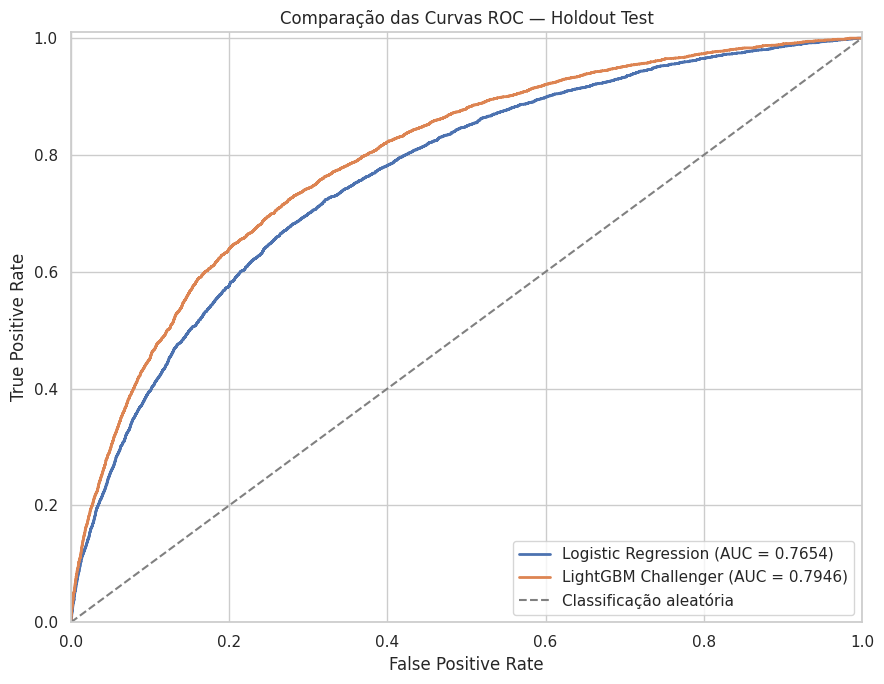

Figura salva em: /content/home-credit-default-risk/reports/figures/model_comparison_holdout_roc_curve.png


In [21]:
# Visualização das curvas ROC no holdout test
figure, axis = plt.subplots(
    figsize=(9, 7)
)

axis.plot(
    traditional_fpr,
    traditional_tpr,
    linewidth=2,
    label=(
        "Logistic Regression "
        f"(AUC = {traditional_auc:.4f})"
    ),
)

axis.plot(
    challenger_fpr,
    challenger_tpr,
    linewidth=2,
    label=(
        "LightGBM Challenger "
        f"(AUC = {challenger_auc:.4f})"
    ),
)

axis.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1.5,
    label="Classificação aleatória",
)

axis.set_title(
    "Comparação das Curvas ROC — Holdout Test"
)

axis.set_xlabel(
    "False Positive Rate"
)

axis.set_ylabel(
    "True Positive Rate"
)

axis.set_xlim(0, 1)
axis.set_ylim(0, 1.01)

axis.legend(
    loc="lower right"
)

figure.tight_layout()

ROC_COMPARISON_PATH = (
    paths.figures
    / "model_comparison_holdout_roc_curve.png"
)

figure.savefig(
    ROC_COMPARISON_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"Figura salva em: {ROC_COMPARISON_PATH}"
)

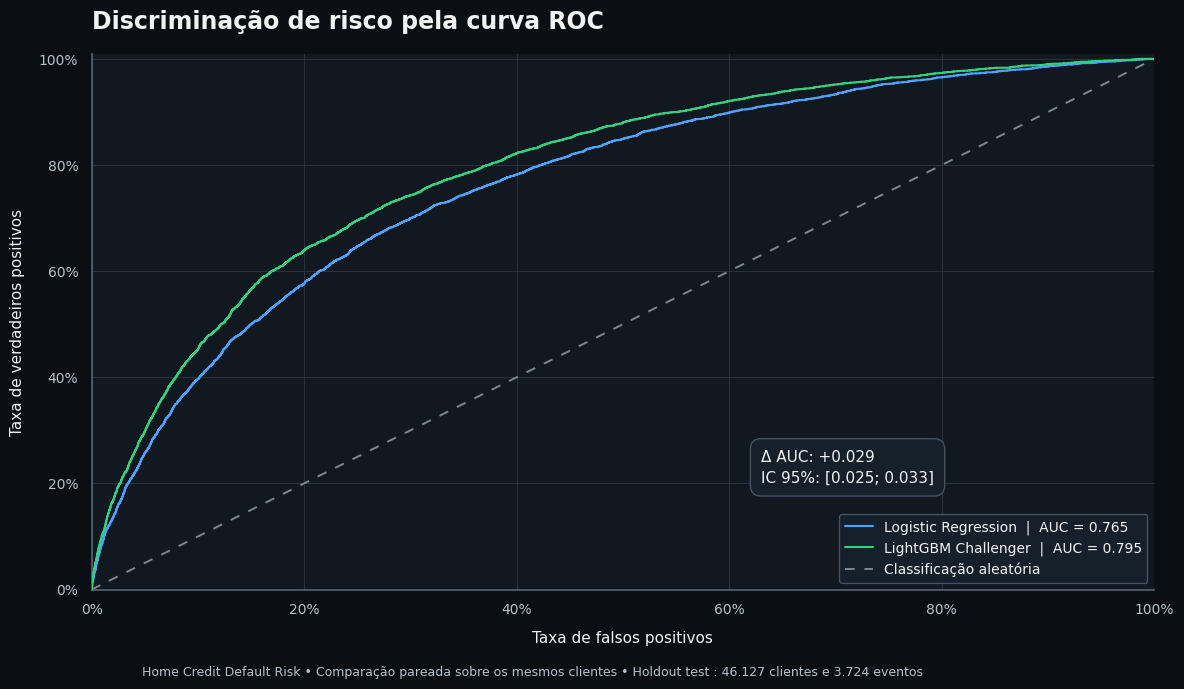

Figura dark salva em: /content/home-credit-default-risk/reports/figures/model_comparison_holdout_roc_curve_dark.png
Figura dark para divulgação salva em: /content/home-credit-default-risk/reports/figures/model_comparison_holdout_roc_curve_linkedin_dark.png


In [46]:
# Visualização dark das curvas ROC no holdout test
from matplotlib.ticker import PercentFormatter

background_color = "#0B0F14"
plot_background_color = "#111820"

traditional_color = "#4DA3FF"
challenger_color = "#35D07F"
reference_color = "#7D8793"

primary_text_color = "#F2F2F2"
secondary_text_color = "#B8C0CC"
grid_color = "#35404D"

auc_difference = (
    challenger_auc - traditional_auc
)

auc_bootstrap_result = (
    paired_bootstrap_comparison.loc[
        paired_bootstrap_comparison[
            "metric"
        ].eq("roc_auc")
    ]
    .iloc[0]
)

with plt.rc_context(
    {
        "font.family": "sans-serif",
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "axes.titlesize": 17,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "text.color": primary_text_color,
        "axes.labelcolor": primary_text_color,
        "xtick.color": secondary_text_color,
        "ytick.color": secondary_text_color,
    }
):
    figure, axis = plt.subplots(
        figsize=(12, 7),
        facecolor=background_color,
    )

    axis.set_facecolor(
        plot_background_color
    )

    axis.plot(
        traditional_fpr,
        traditional_tpr,
        color=traditional_color,
        linewidth=1.5,
        label=(
            "Logistic Regression"
            f"  |  AUC = {traditional_auc:.3f}"
        ),
        zorder=3,
    )

    axis.plot(
        challenger_fpr,
        challenger_tpr,
        color=challenger_color,
        linewidth=1.5,
        label=(
            "LightGBM Challenger"
            f"  |  AUC = {challenger_auc:.3f}"
        ),
        zorder=4,
    )

    axis.plot(
        [0, 1],
        [0, 1],
        color=reference_color,
        linestyle=(0, (5, 5)),
        linewidth=1.4,
        label="Classificação aleatória",
        zorder=2,
    )

    axis.set_title(
        "Discriminação de risco pela curva ROC",
        loc="left",
        pad=18,
        color=primary_text_color,
    )

    comparison_text = (
        f"Δ AUC: +{auc_difference:.3f}\n"
        "IC 95%: "
        f"[{auc_bootstrap_result['ci_lower_95']:.3f}; "
        f"{auc_bootstrap_result['ci_upper_95']:.3f}]"
    )

    axis.text(
        0.63,
        0.20,
        comparison_text,
        transform=axis.transAxes,
        fontsize=11,
        color=primary_text_color,
        linespacing=1.5,
        bbox={
            "boxstyle": "round,pad=0.7",
            "facecolor": "#17212B",
            "edgecolor": "#465466",
            "linewidth": 1.0,
            "alpha": 0.97,
        },
        zorder=5,
    )

    axis.set_xlabel(
        "Taxa de falsos positivos",
        labelpad=10,
    )

    axis.set_ylabel(
        "Taxa de verdadeiros positivos",
        labelpad=10,
    )

    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1.01)

    axis.xaxis.set_major_formatter(
        PercentFormatter(
            xmax=1,
            decimals=0,
        )
    )

    axis.yaxis.set_major_formatter(
        PercentFormatter(
            xmax=1,
            decimals=0,
        )
    )

    axis.grid(
        visible=True,
        color=grid_color,
        linewidth=0.8,
        alpha=0.65,
    )

    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

    axis.spines["left"].set_color(
        "#536171"
    )

    axis.spines["bottom"].set_color(
        "#536171"
    )

    legend = axis.legend(
        loc="lower right",
        frameon=True,
        facecolor="#17212B",
        edgecolor="#465466",
        framealpha=0.97,
        fontsize=10,
    )

    for legend_text in legend.get_texts():
        legend_text.set_color(
            primary_text_color
        )

    footer_text = (
        "Home Credit Default Risk • "
        "Comparação pareada sobre os mesmos clientes • "
        "Holdout test : "
        f"{len(holdout_data):,} clientes e "
        f"{int(y_holdout.sum()):,} eventos"
    ).replace(",", ".")

    figure.text(
        0.125,
        0.018,
        footer_text,
        fontsize=9,
        color=secondary_text_color,
        linespacing=1.5,
        ha="left",
        va="bottom",
    )

    # figure.tight_layout(
    #     rect=[0, 0.09, 1, 1]
    # )

    figure.tight_layout(
        rect=[0, 0.04, 1, 1]
    )

    ROC_DARK_PATH = (
        paths.figures
        / "model_comparison_holdout_roc_curve_dark.png"
    )

    ROC_LINKEDIN_DARK_PATH = (
        paths.figures
        / (
            "model_comparison_holdout_"
            "roc_curve_linkedin_dark.png"
        )
    )

    figure.savefig(
        ROC_DARK_PATH,
        dpi=180,
        bbox_inches="tight",
        facecolor=background_color,
    )

    figure.savefig(
        ROC_LINKEDIN_DARK_PATH,
        dpi=300,
        bbox_inches="tight",
        facecolor=background_color,
    )

    plt.show()

print(
    "Figura dark salva em: "
    f"{ROC_DARK_PATH}"
)

print(
    "Figura dark para divulgação salva em: "
    f"{ROC_LINKEDIN_DARK_PATH}"
)

### 12. Comparação da Calibração no Holdout Test

A discriminação avalia se o modelo consegue ordenar os clientes por risco. A calibração, por sua vez, avalia se as probabilidades estimadas correspondem às frequências observadas de eventos.

Um modelo pode apresentar boa ROC-AUC e, ainda assim, produzir PDs sistematicamente maiores ou menores que as taxas efetivamente observadas.

Nesta análise, os clientes serão divididos em decis de risco para cada modelo. Em cada decil serão comparadas:

- a PD média estimada;
- a taxa de eventos observada;
- a diferença entre essas duas medidas.

O primeiro decil representa os clientes de menor risco estimado, enquanto o décimo decil representa os clientes de maior risco.

In [22]:
# Função para construir a calibração por decil
def build_calibration_by_decile(
    data,
    probability_column,
    model_name,
    number_of_bins=10,
):
    calibration_data = data[
        [
            TARGET_COLUMN,
            probability_column,
        ]
    ].copy()

    probability_rank = calibration_data[
        probability_column
    ].rank(
        method="first"
    )

    calibration_data["risk_decile"] = (
        pd.qcut(
            probability_rank,
            q=number_of_bins,
            labels=False,
        )
        + 1
    )

    calibration_table = (
        calibration_data
        .groupby(
            "risk_decile",
            observed=True,
        )
        .agg(
            clients=(
                TARGET_COLUMN,
                "size",
            ),
            events=(
                TARGET_COLUMN,
                "sum",
            ),
            minimum_pd=(
                probability_column,
                "min",
            ),
            maximum_pd=(
                probability_column,
                "max",
            ),
            mean_predicted_pd=(
                probability_column,
                "mean",
            ),
            observed_bad_rate=(
                TARGET_COLUMN,
                "mean",
            ),
        )
        .reset_index()
    )

    calibration_table[
        "calibration_difference"
    ] = (
        calibration_table["mean_predicted_pd"]
        - calibration_table["observed_bad_rate"]
    )

    calibration_table.insert(
        0,
        "model",
        model_name,
    )

    return calibration_table

In [23]:
# Construção das tabelas de calibração dos modelos
traditional_holdout_calibration = (
    build_calibration_by_decile(
        data=holdout_data,
        probability_column="traditional_pd",
        model_name="Logistic Regression",
    )
)

challenger_holdout_calibration = (
    build_calibration_by_decile(
        data=holdout_data,
        probability_column="challenger_pd",
        model_name="LightGBM Challenger",
    )
)

holdout_calibration_comparison = pd.concat(
    [
        traditional_holdout_calibration,
        challenger_holdout_calibration,
    ],
    ignore_index=True,
)

display(holdout_calibration_comparison)

,model,risk_decile,clients,events,minimum_pd,maximum_pd,mean_predicted_pd,observed_bad_rate,calibration_difference
0,Logistic Regression,1,4613,59,0.0021,0.0158,0.0112,0.0128,-0.0016
1,Logistic Regression,2,4613,85,0.0158,0.0231,0.0195,0.0184,0.0010
2,Logistic Regression,3,4612,132,0.0231,0.0310,0.0270,0.0286,-0.0016
3,Logistic Regression,4,4613,143,0.0310,0.0402,0.0355,0.0310,0.0045
4,Logistic Regression,5,4613,205,0.0402,0.0516,0.0457,0.0444,0.0012
5,Logistic Regression,6,4612,276,0.0516,0.0667,0.0587,0.0598,-0.0011
6,Logistic Regression,7,4613,335,0.0667,0.0883,0.0768,0.0726,0.0042
7,Logistic Regression,8,4612,508,0.0883,0.1230,0.1038,0.1101,-0.0063
8,Logistic Regression,9,4613,690,0.1230,0.1865,0.1509,0.1496,0.0013
9,Logistic Regression,10,4613,1291,0.1865,0.6588,0.2761,0.2799,-0.0038


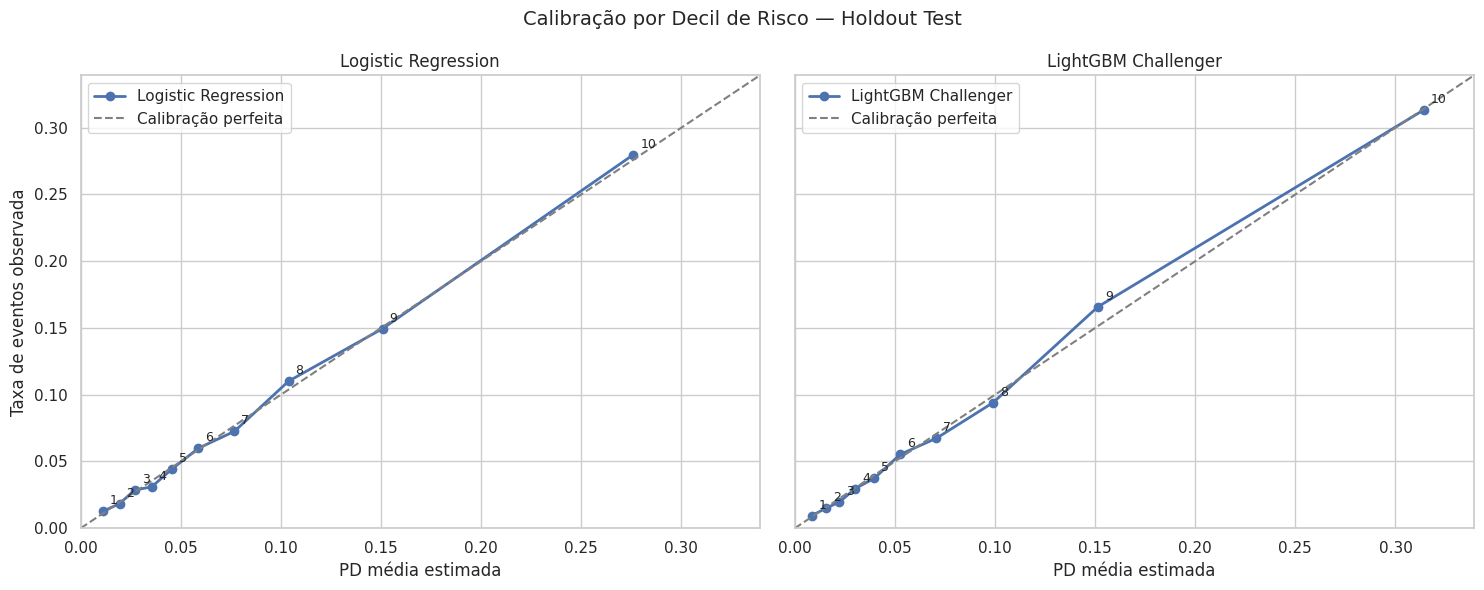

Figura salva em: /content/home-credit-default-risk/reports/figures/model_comparison_holdout_calibration.png


In [24]:
# Visualização da calibração por decil no holdout test
figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 6),
    sharex=True,
    sharey=True,
)

calibration_tables = {
    "Logistic Regression": (
        traditional_holdout_calibration
    ),
    "LightGBM Challenger": (
        challenger_holdout_calibration
    ),
}

maximum_calibration_value = (
    holdout_calibration_comparison[
        [
            "mean_predicted_pd",
            "observed_bad_rate",
        ]
    ]
    .max()
    .max()
)

plot_limit = maximum_calibration_value * 1.08

for axis, (
    model_name,
    calibration_table,
) in zip(
    axes,
    calibration_tables.items(),
):
    axis.plot(
        calibration_table[
            "mean_predicted_pd"
        ],
        calibration_table[
            "observed_bad_rate"
        ],
        marker="o",
        linewidth=2,
        label=model_name,
    )

    axis.plot(
        [0, plot_limit],
        [0, plot_limit],
        linestyle="--",
        color="gray",
        linewidth=1.5,
        label="Calibração perfeita",
    )

    for _, row in calibration_table.iterrows():
        axis.annotate(
            int(row["risk_decile"]),
            (
                row["mean_predicted_pd"],
                row["observed_bad_rate"],
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
        )

    axis.set_title(model_name)
    axis.set_xlabel("PD média estimada")
    axis.set_xlim(0, plot_limit)
    axis.set_ylim(0, plot_limit)
    axis.legend()

axes[0].set_ylabel(
    "Taxa de eventos observada"
)

figure.suptitle(
    "Calibração por Decil de Risco — Holdout Test",
    fontsize=14,
)

figure.tight_layout()

CALIBRATION_COMPARISON_PATH = (
    paths.figures
    / "model_comparison_holdout_calibration.png"
)

figure.savefig(
    CALIBRATION_COMPARISON_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Figura salva em: "
    f"{CALIBRATION_COMPARISON_PATH}"
)

### Interpretação da Calibração Comparativa

Os dois modelos apresentam PD média próxima da taxa observada na maior parte dos decis, indicando boa calibração ao longo das faixas de risco.

A Logistic Regression apresentou diferenças relativamente pequenas e distribuídas entre os decis. O LightGBM também apresentou boa aderência, embora tenha subestimado o risco no nono decil em aproximadamente 1,45 ponto percentual.

No décimo decil, o LightGBM estimou PD média de aproximadamente 31,41%, frente a uma taxa observada de 31,32%, demonstrando boa calibração na faixa de maior risco.

Além disso, o challenger concentrou 1.445 eventos no décimo decil, enquanto a Logistic Regression concentrou 1.291. Essa diferença evidencia a maior capacidade do LightGBM de posicionar clientes com evento nas faixas superiores de risco.

O melhor Brier Score global do LightGBM não implica necessariamente menor diferença em todos os decis. O Brier Score é calculado no nível individual e combina componentes de calibração e discriminação, enquanto a análise por decis compara médias agregadas.

## Concordância entre os Modelos

### 13. Correlação e Migração entre Decis

A substituição de um modelo tradicional por um challenger pode alterar a posição relativa dos clientes na escala de risco. Por isso, além das métricas agregadas, é necessário avaliar a concordância entre as ordenações produzidas.

A correlação de Spearman será utilizada para medir a associação monotônica entre as PDs. Valores próximos de 1 indicam que os modelos produzem rankings semelhantes, mesmo que as probabilidades estimadas sejam diferentes.

Também será construída uma matriz de migração entre decis. Essa matriz permite identificar quantos clientes permanecem na mesma faixa de risco e quantos são deslocados para decis superiores ou inferiores quando o modelo é alterado.

In [25]:
# Construção dos decis de risco dos dois modelos
holdout_ranking_comparison = (
    holdout_data.copy()
)

holdout_ranking_comparison[
    "traditional_decile"
] = (
    pd.qcut(
        holdout_ranking_comparison[
            "traditional_pd"
        ].rank(method="first"),
        q=10,
        labels=False,
    )
    + 1
)

holdout_ranking_comparison[
    "challenger_decile"
] = (
    pd.qcut(
        holdout_ranking_comparison[
            "challenger_pd"
        ].rank(method="first"),
        q=10,
        labels=False,
    )
    + 1
)

In [26]:
# Cálculo da concordância entre os rankings
spearman_correlation, spearman_p_value = (
    spearmanr(
        holdout_ranking_comparison[
            "traditional_pd"
        ],
        holdout_ranking_comparison[
            "challenger_pd"
        ],
    )
)

decile_difference = (
    holdout_ranking_comparison[
        "challenger_decile"
    ]
    - holdout_ranking_comparison[
        "traditional_decile"
    ]
)

ranking_agreement_summary = pd.DataFrame(
    {
        "metric": [
            "Spearman correlation",
            "Spearman p-value",
            "Same decile rate",
            "Within one decile rate",
            "Mean absolute decile migration",
            "Maximum absolute decile migration",
        ],
        "value": [
            spearman_correlation,
            spearman_p_value,
            decile_difference.eq(0).mean(),
            decile_difference.abs().le(1).mean(),
            decile_difference.abs().mean(),
            decile_difference.abs().max(),
        ],
    }
)

display(ranking_agreement_summary)

,metric,value
0,Spearman correlation,0.8702
1,Spearman p-value,0.0000
2,Same decile rate,0.3403
3,Within one decile rate,0.7220
4,Mean absolute decile migration,1.0785
5,Maximum absolute decile migration,7.0000


In [27]:
# Construção da matriz de migração entre decis
decile_migration_counts = pd.crosstab(
    holdout_ranking_comparison[
        "traditional_decile"
    ],
    holdout_ranking_comparison[
        "challenger_decile"
    ],
    rownames=[
        "Decil — Logistic Regression"
    ],
    colnames=[
        "Decil — LightGBM Challenger"
    ],
)

decile_migration_percent = pd.crosstab(
    holdout_ranking_comparison[
        "traditional_decile"
    ],
    holdout_ranking_comparison[
        "challenger_decile"
    ],
    normalize="index",
) * 100

display(decile_migration_counts)

Decil — LightGBM Challenger,1,2,3,4,5,6,7,8,9,10
Decil — Logistic Regression,,,,,,,,,,
1,2559,1163,548,195,96,42,9,1,0,0
2,1256,1362,958,524,322,126,52,11,2,0
3,506,1021,1130,917,541,302,137,49,8,1
4,189,606,937,1072,830,565,275,105,31,3
5,67,300,577,916,1024,808,569,275,72,5
6,30,120,301,578,906,1068,847,538,198,26
7,5,33,125,279,572,912,1131,1001,470,85
8,1,8,32,112,251,570,1020,1350,1016,252
9,0,0,4,18,67,203,504,1041,1769,1007


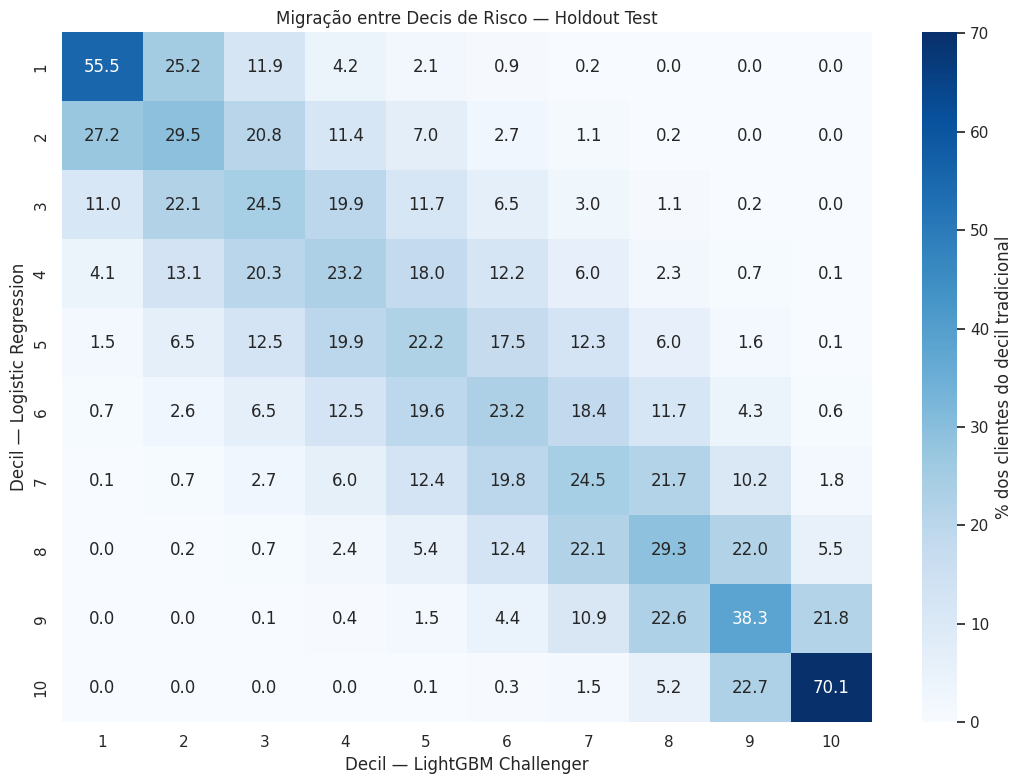

Figura salva em: /content/home-credit-default-risk/reports/figures/model_comparison_decile_migration.png


In [28]:
# Visualização da matriz de migração entre decis
figure, axis = plt.subplots(
    figsize=(11, 8)
)

sns.heatmap(
    decile_migration_percent,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={
        "label": (
            "% dos clientes do decil tradicional"
        )
    },
    ax=axis,
)

axis.set_title(
    "Migração entre Decis de Risco — Holdout Test"
)

axis.set_xlabel(
    "Decil — LightGBM Challenger"
)

axis.set_ylabel(
    "Decil — Logistic Regression"
)

figure.tight_layout()

DECILE_MIGRATION_PATH = (
    paths.figures
    / "model_comparison_decile_migration.png"
)

figure.savefig(
    DECILE_MIGRATION_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"Figura salva em: {DECILE_MIGRATION_PATH}"
)

### Interpretação da Concordância entre os Modelos

A correlação de Spearman entre as PDs foi de aproximadamente 0,87, indicando forte associação entre as ordenações produzidas pelos dois modelos.

Apesar dessa concordância elevada, apenas 34,03% dos clientes permaneceram exatamente no mesmo decil. Quando se permite uma diferença de até um decil, a concordância aumenta para 72,20%.

A migração absoluta média foi de aproximadamente 1,08 decil. Isso significa que, em média, a substituição da Logistic Regression pelo LightGBM desloca cada cliente pouco mais de uma faixa na distribuição de risco.

Os decis extremos apresentaram maior estabilidade. Cerca de 55% dos clientes posicionados no primeiro decil pela Logistic Regression permaneceram no primeiro decil do LightGBM. No décimo decil, aproximadamente 70% permaneceram na faixa de maior risco.

Não foram observadas migrações diretas entre o primeiro e o décimo decil. Entretanto, a migração máxima de sete decis mostra que existem casos individuais com divergências relevantes entre os modelos.

Portanto, o challenger não produz uma ordenação completamente diferente, mas também não representa apenas uma transformação monotônica do modelo tradicional. A mudança de modelo pode alterar decisões individuais, especialmente para clientes próximos aos cutoffs de uma Política de Crédito.

## Fairness e Governança

### 14. Diagnóstico de Performance por Grupo

A feature `CODE_GENDER` foi utilizada pelo LightGBM e apresentou relevância na análise por SHAP. Por representar um atributo sensível, sua utilização exige atenção especial de governança.

Nesta etapa, serão comparados entre os grupos:

- quantidade de clientes;
- taxa observada de eventos;
- PD média estimada;
- diferença de calibração global;
- ROC-AUC;
- PR-AUC;
- Brier Score.

Os resultados possuem caráter exploratório. Diferenças de performance ou de risco médio entre grupos não comprovam, isoladamente, tratamento discriminatório, pois podem refletir diferenças na composição da população e nas demais características observadas.

Da mesma forma, métricas semelhantes não garantem fairness. Uma avaliação completa exigiria definição institucional dos critérios de equidade, revisão jurídica e regulatória, análise das variáveis correlacionadas e testes adicionais de impacto da Política de Crédito.

In [29]:
# Localização da base com o atributo sensível
gender_column = "CODE_GENDER"

processed_data_candidates = [
    paths.data_processed
    / "modeling_holdout_test_full.parquet",
    paths.data_processed
    / "modeling_holdout_test.parquet",
]

holdout_features_path = next(
    (
        candidate_path
        for candidate_path in processed_data_candidates
        if candidate_path.exists()
    ),
    None,
)

if holdout_features_path is None:
    available_parquet_files = sorted(
        path.name
        for path in paths.data_processed.glob(
            "*.parquet"
        )
    )

    raise FileNotFoundError(
        "A base completa do holdout não foi "
        "encontrada. Arquivos disponíveis: "
        f"{available_parquet_files}"
    )

print(
    "Base selecionada: "
    f"{holdout_features_path}"
)

Base selecionada: /content/drive/MyDrive/home-credit-default-risk/data/processed/modeling_holdout_test_full.parquet


In [30]:
# Carregamento do atributo sensível
holdout_group_attributes = pd.read_parquet(
    holdout_features_path,
    columns=[
        ID_COLUMN,
        gender_column,
    ],
)

if holdout_group_attributes[
    ID_COLUMN
].duplicated().any():
    raise ValueError(
        "Existem identificadores duplicados "
        "na base de atributos do holdout."
    )

holdout_group_analysis_data = (
    holdout_data.merge(
        holdout_group_attributes,
        on=ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
)

if holdout_group_analysis_data[
    gender_column
].isna().any():
    raise ValueError(
        "Existem clientes sem CODE_GENDER "
        "após o cruzamento."
    )

display(
    holdout_group_analysis_data[
        gender_column
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(gender_column)
    .reset_index(name="clients")
)

,CODE_GENDER,clients
0,F,30429
1,M,15698


In [31]:
# Função para calcular métricas por grupo
def calculate_group_metrics(
    data,
    group_column,
    probability_column,
    model_name,
):
    group_metric_records = []

    for group_value, group_data in data.groupby(
        group_column,
        observed=True,
    ):
        y_group = group_data[
            TARGET_COLUMN
        ].to_numpy()

        probability_group = group_data[
            probability_column
        ].to_numpy()

        group_metrics = calculate_binary_metrics(
            y_true=y_group,
            predicted_probability=(
                probability_group
            ),
        )

        group_metric_records.append(
            {
                "model": model_name,
                "group": group_value,
                "clients": len(group_data),
                "events": int(y_group.sum()),
                **group_metrics,
                "calibration_difference": (
                    group_metrics[
                        "mean_predicted_pd"
                    ]
                    - group_metrics[
                        "observed_event_rate"
                    ]
                ),
            }
        )

    return pd.DataFrame(
        group_metric_records
    )

In [32]:
# Cálculo das métricas dos modelos por grupo
traditional_group_metrics = (
    calculate_group_metrics(
        data=holdout_group_analysis_data,
        group_column=gender_column,
        probability_column="traditional_pd",
        model_name="Logistic Regression",
    )
)

challenger_group_metrics = (
    calculate_group_metrics(
        data=holdout_group_analysis_data,
        group_column=gender_column,
        probability_column="challenger_pd",
        model_name="LightGBM Challenger",
    )
)

group_model_comparison = pd.concat(
    [
        traditional_group_metrics,
        challenger_group_metrics,
    ],
    ignore_index=True,
)

group_model_comparison = (
    group_model_comparison
    .sort_values(
        ["group", "model"]
    )
    .reset_index(drop=True)
)

display(group_model_comparison)

,model,group,clients,events,roc_auc,gini,ks,pr_auc,brier_score,log_loss,mean_predicted_pd,observed_event_rate,calibration_difference
0,LightGBM Challenger,F,30429,2118,0.7878,0.5757,0.4347,0.2634,0.0578,0.2135,0.0698,0.0696,0.0002
1,Logistic Regression,F,30429,2118,0.7632,0.5264,0.4013,0.2286,0.0593,0.2208,0.0697,0.0696,0.0001
2,LightGBM Challenger,M,15698,1606,0.7939,0.5878,0.4542,0.3214,0.0802,0.2756,0.1011,0.1023,-0.0012
3,Logistic Regression,M,15698,1606,0.7546,0.5091,0.3827,0.2700,0.0835,0.2900,0.1015,0.1023,-0.0008


### Interpretação do Diagnóstico por Grupo

A amostra contém 30.429 clientes no grupo `F` e 15.698 clientes no grupo `M`. As respectivas taxas observadas de eventos foram de aproximadamente 6,96% e 10,23%.

Essa diferença representa uma característica observada na base e não deve ser interpretada, isoladamente, como justificativa para tratamentos distintos em uma Política de Crédito.

Os dois modelos apresentaram boa calibração global dentro de cada grupo. As diferenças entre a PD média e a taxa observada ficaram abaixo de 0,12 ponto percentual em valor absoluto.

O LightGBM apresentou melhor discriminação nos dois grupos:

- no grupo `F`, a ROC-AUC aumentou de aproximadamente 0,763 para 0,788;
- no grupo `M`, a ROC-AUC aumentou de aproximadamente 0,755 para 0,794;
- o challenger também apresentou maior KS e PR-AUC em ambos os grupos.

Os valores de Brier Score, Log Loss e PR-AUC não devem ser comparados diretamente entre os grupos sem considerar as diferentes taxas de eventos. Essas métricas são influenciadas pela prevalência do target.

Os resultados indicam que o ganho do challenger não está restrito a apenas um dos grupos analisados. Entretanto, essa análise não demonstra ausência de viés ou fairness. A avaliação completa dependeria da definição institucional do critério de equidade, da análise das decisões produzidas pela Política de Crédito e da revisão da utilização de atributos sensíveis e de possíveis proxies.

### 15. Verificação do Uso do Atributo Sensível

A análise de métricas por grupo avalia o comportamento dos modelos, mas não informa se o atributo sensível foi utilizado diretamente no cálculo das previsões.

A utilização direta de `CODE_GENDER`, ou de outras variáveis sensíveis, deve ser tratada como uma decisão de governança separada da performance estatística. Uma feature pode melhorar a capacidade preditiva e ainda assim ser considerada inadequada para utilização em uma decisão de crédito.

A seguir, será verificado se `CODE_GENDER` consta nas listas finais de features dos dois modelos.

In [33]:
# Localização dos arquivos de features dos modelos
traditional_features_path = (
    paths.metadata
    / "traditional_final_features.json"
)

challenger_features_path = (
    paths.metadata
    / "lightgbm_challenger_features.json"
)

for feature_path in [
    traditional_features_path,
    challenger_features_path,
]:
    if not feature_path.exists():
        raise FileNotFoundError(
            f"Arquivo não encontrado: {feature_path}"
        )

In [34]:
# Leitura das listas de features
with open(
    traditional_features_path,
    mode="r",
    encoding="utf-8",
) as file:
    traditional_features_metadata = json.load(
        file
    )

with open(
    challenger_features_path,
    mode="r",
    encoding="utf-8",
) as file:
    challenger_features_metadata = json.load(
        file
    )

print(
    "Tipo do artefato tradicional:",
    type(traditional_features_metadata).__name__,
)

print(
    "Tipo do artefato challenger:",
    type(challenger_features_metadata).__name__,
)

if isinstance(
    traditional_features_metadata,
    dict,
):
    print(
        "Chaves do artefato tradicional:",
        list(
            traditional_features_metadata.keys()
        ),
    )

if isinstance(
    challenger_features_metadata,
    dict,
):
    print(
        "Chaves do artefato challenger:",
        list(
            challenger_features_metadata.keys()
        ),
    )

Tipo do artefato tradicional: list
Tipo do artefato challenger: list


In [35]:
# Verificação do uso direto de CODE_GENDER
sensitive_feature_usage = pd.DataFrame(
    {
        "model": [
            "Logistic Regression",
            "LightGBM Challenger",
        ],
        "number_of_features": [
            len(traditional_features_metadata),
            len(challenger_features_metadata),
        ],
        "uses_code_gender": [
            gender_column
            in traditional_features_metadata,
            gender_column
            in challenger_features_metadata,
        ],
    }
)

display(sensitive_feature_usage)

,model,number_of_features,uses_code_gender
0,Logistic Regression,48,True
1,LightGBM Challenger,325,True


In [36]:
# Exibição da posição de CODE_GENDER nas listas
for model_name, feature_list in {
    "Logistic Regression": (
        traditional_features_metadata
    ),
    "LightGBM Challenger": (
        challenger_features_metadata
    ),
}.items():
    if gender_column in feature_list:
        feature_position = (
            feature_list.index(gender_column)
        )

        print(
            f"{model_name}: CODE_GENDER está "
            f"presente na posição "
            f"{feature_position}."
        )
    else:
        print(
            f"{model_name}: CODE_GENDER não "
            "está presente."
        )

Logistic Regression: CODE_GENDER está presente na posição 28.
LightGBM Challenger: CODE_GENDER está presente na posição 1.


### Interpretação do Uso do Atributo Sensível

A variável `CODE_GENDER` está presente nas features finais dos dois modelos:

- Logistic Regression: 48 features finais;
- LightGBM Challenger: 325 features finais.

A presença da variável não permite concluir, isoladamente, que o modelo produz decisões discriminatórias. Entretanto, confirma que as previsões podem depender diretamente do atributo sensível.

No LightGBM, a análise SHAP realizada anteriormente posicionou `CODE_GENDER` entre as variáveis de maior impacto médio. Portanto, sua utilização não pode ser tratada como meramente residual.

Em uma aplicação real, a recomendação seria desenvolver e comparar versões alternativas sem a utilização direta de `CODE_GENDER`, além de investigar possíveis proxies e avaliar os impactos sobre aprovação, bad rate e distribuição das decisões entre grupos.

Neste projeto, os modelos serão mantidos como benchmarks estatísticos construídos sobre uma base pública. A eventual escolha de um champion representa uma conclusão de performance para fins de portfólio, não uma recomendação automática de implantação em produção.

## Seleção do Champion

### 16. Avaliação Multicritério

A escolha entre o modelo tradicional e o challenger deve equilibrar ganho estatístico, interpretabilidade, complexidade operacional e requisitos de governança.

A ROC-AUC isoladamente não é suficiente para determinar qual modelo deve ser adotado. Um modelo com melhor discriminação pode apresentar maior complexidade, maior overfitting, menor transparência ou restrições relacionadas às features utilizadas.

A avaliação a seguir considera:

- discriminação;
- qualidade das probabilidades;
- calibração;
- estabilidade entre amostras;
- overfitting;
- interpretabilidade;
- complexidade;
- incerteza estatística;
- fairness e governança.

In [37]:
# Construção da avaliação multicritério
champion_evaluation = pd.DataFrame(
    [
        {
            "dimension": "Discriminação",
            "traditional_evidence": (
                "AUC 0,7654; KS 0,4018"
            ),
            "challenger_evidence": (
                "AUC 0,7946; KS 0,4484"
            ),
            "advantage": "LightGBM Challenger",
        },
        {
            "dimension": (
                "Qualidade probabilística"
            ),
            "traditional_evidence": (
                "Brier 0,0675; Log Loss 0,2443"
            ),
            "challenger_evidence": (
                "Brier 0,0654; Log Loss 0,2346"
            ),
            "advantage": "LightGBM Challenger",
        },
        {
            "dimension": "Calibração global",
            "traditional_evidence": (
                "PD média 0,0805; "
                "event rate 0,0807"
            ),
            "challenger_evidence": (
                "PD média 0,0804; "
                "event rate 0,0807"
            ),
            "advantage": "Comparável",
        },
        {
            "dimension": (
                "Calibração por decis"
            ),
            "traditional_evidence": (
                "Desvios reduzidos nos decis"
            ),
            "challenger_evidence": (
                "Maior desvio no nono decil"
            ),
            "advantage": "Logistic Regression",
        },
        {
            "dimension": (
                "Generalização no holdout"
            ),
            "traditional_evidence": (
                "AUC validation 0,7618; "
                "holdout 0,7654"
            ),
            "challenger_evidence": (
                "AUC validation 0,7912; "
                "holdout 0,7946"
            ),
            "advantage": "Comparável",
        },
        {
            "dimension": "Overfitting",
            "traditional_evidence": (
                "Gap train-validation reduzido"
            ),
            "challenger_evidence": (
                "Gap train-validation maior"
            ),
            "advantage": "Logistic Regression",
        },
        {
            "dimension": "Interpretabilidade",
            "traditional_evidence": (
                "WoE e coeficientes lineares"
            ),
            "challenger_evidence": (
                "Gain e SHAP"
            ),
            "advantage": "Logistic Regression",
        },
        {
            "dimension": "Complexidade",
            "traditional_evidence": (
                "48 features; modelo linear"
            ),
            "challenger_evidence": (
                "325 features; ensemble"
            ),
            "advantage": "Logistic Regression",
        },
        {
            "dimension": (
                "Incerteza estatística"
            ),
            "traditional_evidence": (
                "Inferior no paired bootstrap"
            ),
            "challenger_evidence": (
                "Superior em 100% das "
                "reamostragens"
            ),
            "advantage": "LightGBM Challenger",
        },
        {
            "dimension": (
                "Fairness e governança"
            ),
            "traditional_evidence": (
                "Utiliza CODE_GENDER"
            ),
            "challenger_evidence": (
                "Utiliza CODE_GENDER com "
                "relevância material"
            ),
            "advantage": "Revisão necessária",
        },
    ]
)

display(champion_evaluation)

,dimension,traditional_evidence,challenger_evidence,advantage
0,Discriminação,"AUC 0,7654; KS 0,4018","AUC 0,7946; KS 0,4484",LightGBM Challenger
1,Qualidade probabilística,"Brier 0,0675; Log Loss 0,2443","Brier 0,0654; Log Loss 0,2346",LightGBM Challenger
2,Calibração global,"PD média 0,0805; event rate 0,0807","PD média 0,0804; event rate 0,0807",Comparável
3,Calibração por decis,Desvios reduzidos nos decis,Maior desvio no nono decil,Logistic Regression
4,Generalização no holdout,"AUC validation 0,7618; holdout 0,7654","AUC validation 0,7912; holdout 0,7946",Comparável
5,Overfitting,Gap train-validation reduzido,Gap train-validation maior,Logistic Regression
6,Interpretabilidade,WoE e coeficientes lineares,Gain e SHAP,Logistic Regression
7,Complexidade,48 features; modelo linear,325 features; ensemble,Logistic Regression
8,Incerteza estatística,Inferior no paired bootstrap,Superior em 100% das reamostragens,LightGBM Challenger
9,Fairness e governança,Utiliza CODE_GENDER,Utiliza CODE_GENDER com relevância material,Revisão necessária


In [38]:
# Registro da decisão de champion
champion_decision = {
    "statistical_champion": (
        "LightGBM Challenger"
    ),
    "interpretable_benchmark": (
        "Logistic Regression"
    ),
    "decision_basis": (
        "Superioridade consistente nas "
        "métricas do holdout e no paired "
        "bootstrap."
    ),
    "governance_condition": (
        "Avaliar versão sem CODE_GENDER e "
        "possíveis proxies antes de qualquer "
        "aplicação real."
    ),
    "usage_scope": (
        "Benchmark e simulação de Política "
        "de Crédito para fins de portfólio."
    ),
}

display(
    pd.DataFrame(
        champion_decision.items(),
        columns=[
            "decision_item",
            "description",
        ],
    )
)

,decision_item,description
0,statistical_champion,LightGBM Challenger
1,interpretable_benchmark,Logistic Regression
2,decision_basis,Superioridade consistente nas métricas do hold...
3,governance_condition,Avaliar versão sem CODE_GENDER e possíveis pro...
4,usage_scope,Benchmark e simulação de Política de Crédito p...


### Decisão

O LightGBM será selecionado como **statistical champion** do projeto, pois apresentou desempenho superior à Logistic Regression em todas as métricas do holdout e em 100% das reamostragens do paired bootstrap.

A Logistic Regression será mantida como **interpretable benchmark**, oferecendo uma referência tradicional baseada em Binning, WoE, IV e coeficientes lineares.

A escolha do LightGBM não representa aprovação para implantação em produção. O modelo utiliza diretamente `CODE_GENDER`, variável sensível que apresentou relevância material na análise por SHAP.

Antes de uma aplicação real, seria necessário desenvolver uma versão sem esse atributo, investigar possíveis proxies, realizar validação temporal, revisar os critérios de fairness e avaliar o impacto das previsões dentro de uma Política de Crédito.

Para as próximas etapas, o LightGBM será utilizado na transformação de PD em score, na criação das faixas de risco e na simulação ilustrativa de cutoffs.